In [87]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [88]:
df=pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [90]:
df.describe() #numeric only

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [91]:
df.describe(include='object') #categorical only

,Species
count,150
unique,3
top,Iris-setosa
freq,50


In [92]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [93]:
df.duplicated().sum()

np.int64(0)

Dropping Id column because it is not useful for our model

In [94]:
df.drop('Id',axis=1,inplace=True)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


#### EDA

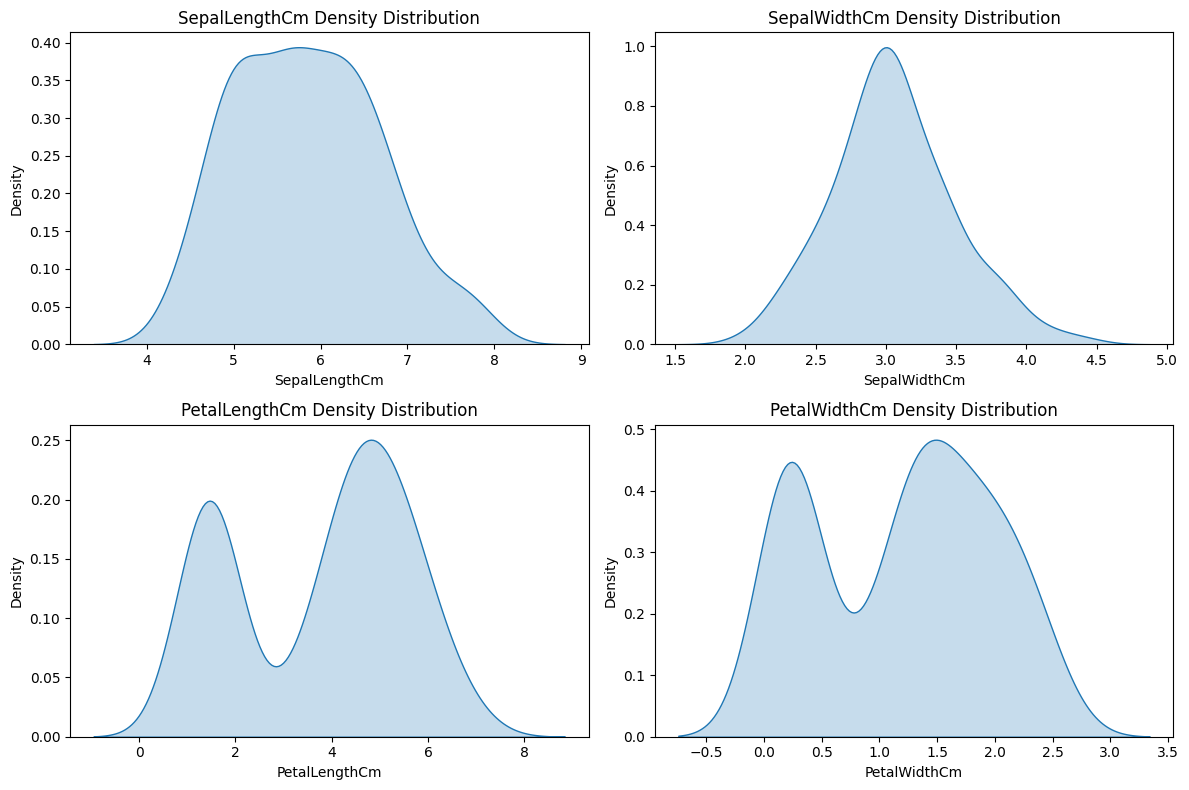

In [95]:
numeric=['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']
plt.figure(figsize=(12,8))
for val,i in zip(numeric,range(1,len(numeric)+1)):
    plt.subplot(2,2,i)
    sns.kdeplot(x=df[val],fill=True)
    plt.xlabel(val)
    plt.ylabel("Density")
    plt.title(f"{val} Density Distribution")
plt.tight_layout()
plt.show()

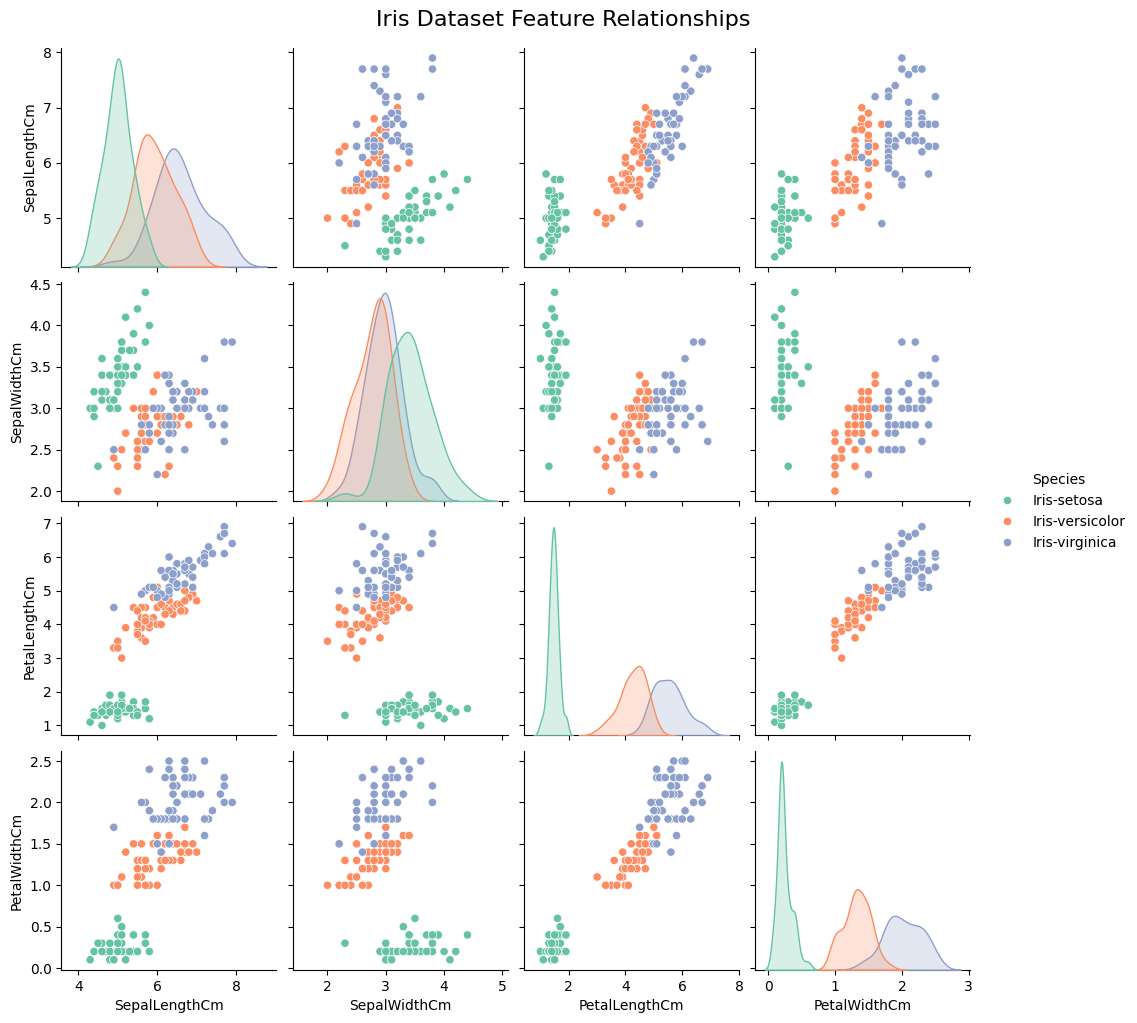

In [96]:
pair_plot = sns.pairplot(
    df,
    hue="Species",
    palette="Set2",
    height=2.5
)
pair_plot.fig.suptitle(
    "Iris Dataset Feature Relationships",
    y=1.02,
    fontsize=16
)
plt.show()

In [97]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

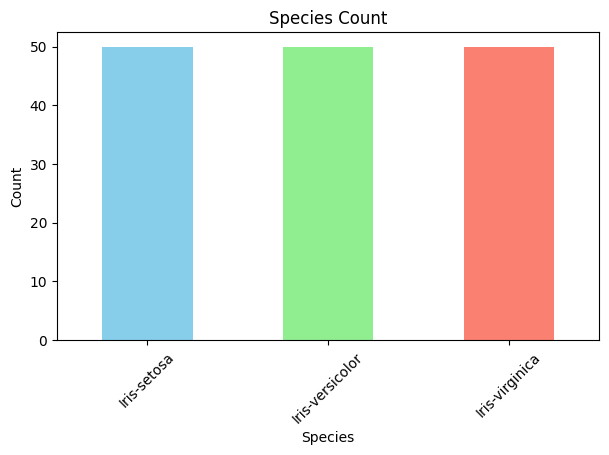

In [98]:
plt.figure(figsize=(7,4))
df['Species'].value_counts().plot(kind='bar',color=['skyblue', 'lightgreen', 'salmon'])
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.title("Species Count")
plt.show()

Correlation Heatmap

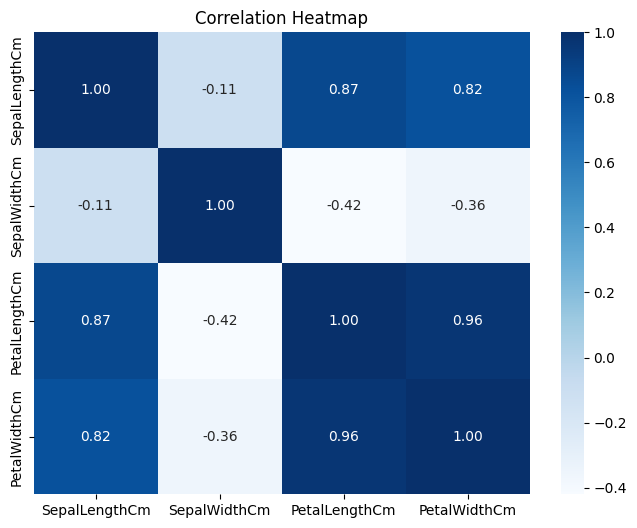

In [99]:
plt.figure(figsize=(8,6))
correlation=df.corr(numeric_only=True)
sns.heatmap(correlation,annot=True,cmap='Blues',fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

Checking for outliers

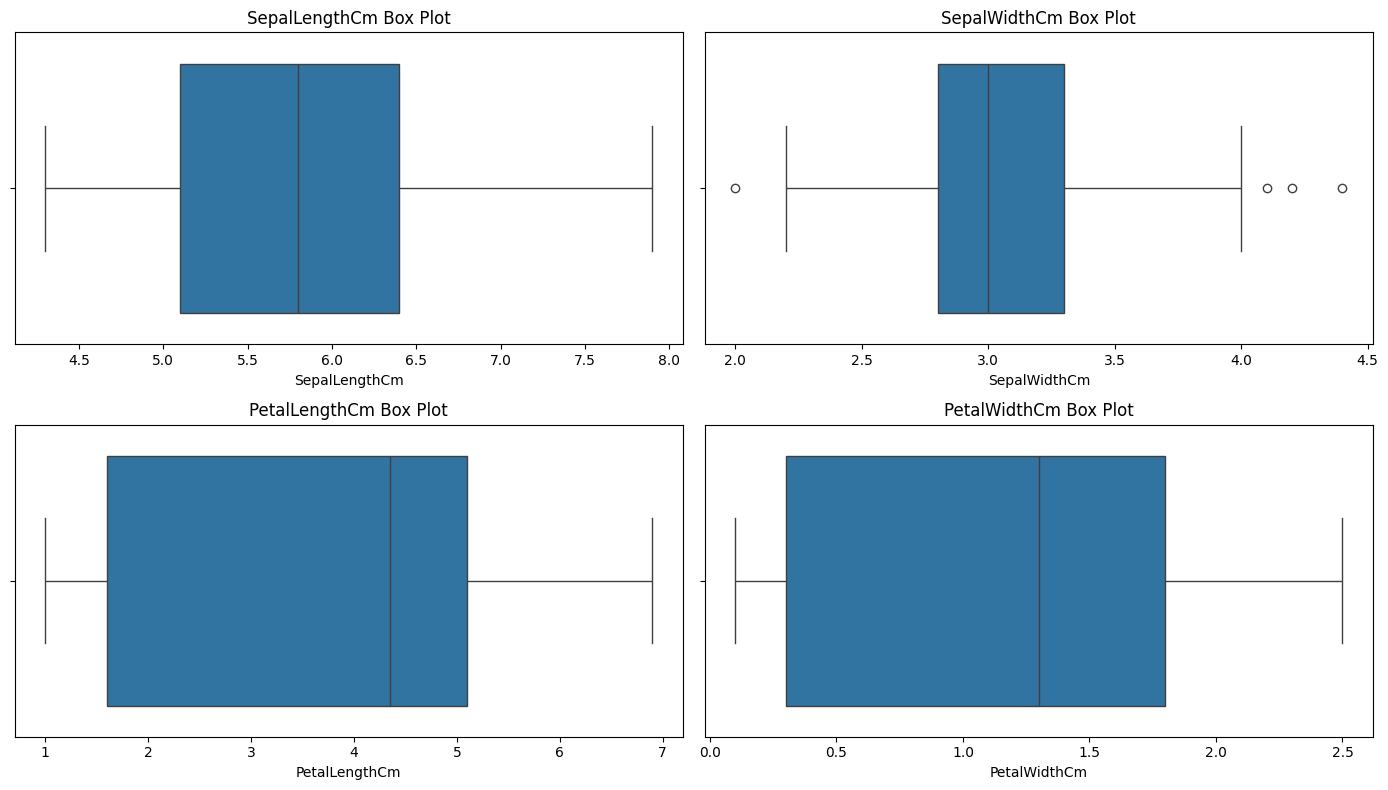

In [100]:
plt.figure(figsize=(14,8))
for val,i in zip(numeric,range(1,len(numeric)+1)):
    plt.subplot(2,2,i)
    sns.boxplot(x=df[val])
    plt.title(f"{val} Box Plot")
plt.tight_layout()
plt.show()

SepalWidthCm contains some outliers, but they represent natural variation in the dataset, so they were kept

In [101]:
X=df.drop(['Species'],axis=1)
y=df['Species']
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Converting target column to numeric

In [102]:
from sklearn.preprocessing import LabelEncoder 
le=LabelEncoder()
y=le.fit_transform(df['Species'])
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [103]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True,stratify=y)

In [104]:
from sklearn.preprocessing import MinMaxScaler
mm=MinMaxScaler()
X_train=mm.fit_transform(X_train)
X_test=mm.transform(X_test)

In [105]:
X_train[:5]

array([[0.02777778, 0.375     , 0.05172414, 0.04166667],
       [0.16666667, 0.20833333, 0.5862069 , 0.66666667],
       [0.69444444, 0.33333333, 0.63793103, 0.54166667],
       [0.16666667, 0.45833333, 0.06896552, 0.        ],
       [0.33333333, 0.20833333, 0.5       , 0.5       ]])

This is classification problem since target column is categorical\
We will try multiple classification models

In [106]:
from sklearn.linear_model import LogisticRegression,RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.naive_bayes import GaussianNB 
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
models=['Logistic Regression', 'Ridge Classifier','KNN','SVM','Decision Tree','Random Forest','Gaussian Naive Bayes']
#logistic regression
logistic_regressor=LogisticRegression()
logistic_regressor.fit(X_train,y_train)
y_pred_lr=logistic_regressor.predict(X_test)
#ridge classifier
ridge_classifier_model=RidgeClassifier()
ridge_classifier_model.fit(X_train,y_train)
y_pred_ridge=ridge_classifier_model.predict(X_test)
#knn
knn=KNeighborsClassifier()
knn.fit(X_train,y_train)
y_pred_knn=knn.predict(X_test)
#svm
svm=SVC()
svm.fit(X_train,y_train)
y_pred_svm=svm.predict(X_test)
#decision tree
decision_tree_model=DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train,y_train)
y_pred_dt=decision_tree_model.predict(X_test)
#random forest
random_forest_model=RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train,y_train)
y_pred_rf=random_forest_model.predict(X_test)
#gaussian nb
gaussian_nb_model=GaussianNB()
gaussian_nb_model.fit(X_train,y_train)
y_pred_nb=gaussian_nb_model.predict(X_test)

In [107]:
results = pd.DataFrame({
    "Model": models,
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_ridge),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, average='weighted'),
        precision_score(y_test, y_pred_ridge, average='weighted'),
        precision_score(y_test, y_pred_knn, average='weighted'),
        precision_score(y_test, y_pred_svm, average='weighted'),
        precision_score(y_test, y_pred_dt, average='weighted'),
        precision_score(y_test, y_pred_rf, average='weighted'),
        precision_score(y_test, y_pred_nb, average='weighted')
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, average='weighted'),
        recall_score(y_test, y_pred_ridge, average='weighted'),
        recall_score(y_test, y_pred_knn, average='weighted'),
        recall_score(y_test, y_pred_svm, average='weighted'),
        recall_score(y_test, y_pred_dt, average='weighted'),
        recall_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_nb, average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_ridge, average='weighted'),
        f1_score(y_test, y_pred_knn, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted'),
        f1_score(y_test, y_pred_dt, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_nb, average='weighted')
    ]
})

results = (
    results
    .sort_values(
        by=["Accuracy", "F1 Score", "Precision", "Recall"],
        ascending=False
    )
    .round(4)
    .reset_index(drop=True)
)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.9667,0.9697,0.9667,0.9666
1,SVM,0.9667,0.9697,0.9667,0.9666
2,Gaussian Naive Bayes,0.9667,0.9697,0.9667,0.9666
3,Decision Tree,0.9333,0.9333,0.9333,0.9333
4,Logistic Regression,0.9000,0.9024,0.9000,0.8997
5,Random Forest,0.9000,0.9024,0.9000,0.8997
6,Ridge Classifier,0.7667,0.8000,0.7667,0.7511


In [108]:
from sklearn.model_selection import cross_val_score

models_cv = {
    "Logistic Regression": logistic_regressor,
    "Ridge Classifier": ridge_classifier_model,
    "KNN": knn,
    "SVM": svm,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "Gaussian Naive Bayes": gaussian_nb_model
}


cv_results = []

for name, model in models_cv.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5
    )
    
    cv_results.append({
        "Model": name,
        "Mean CV Accuracy": scores.mean(),
        "Std": scores.std()
    })


cv_results = pd.DataFrame(cv_results)

cv_results = (
    cv_results
    .sort_values(by="Mean CV Accuracy", ascending=False)
    .round(4)
    .reset_index(drop=True)
)

cv_results

,Model,Mean CV Accuracy,Std
0,Logistic Regression,0.9733,0.0249
1,KNN,0.9733,0.0249
2,Random Forest,0.9667,0.0211
3,SVM,0.9667,0.0211
4,Decision Tree,0.9533,0.0340
5,Gaussian Naive Bayes,0.9533,0.0267
6,Ridge Classifier,0.8200,0.0499


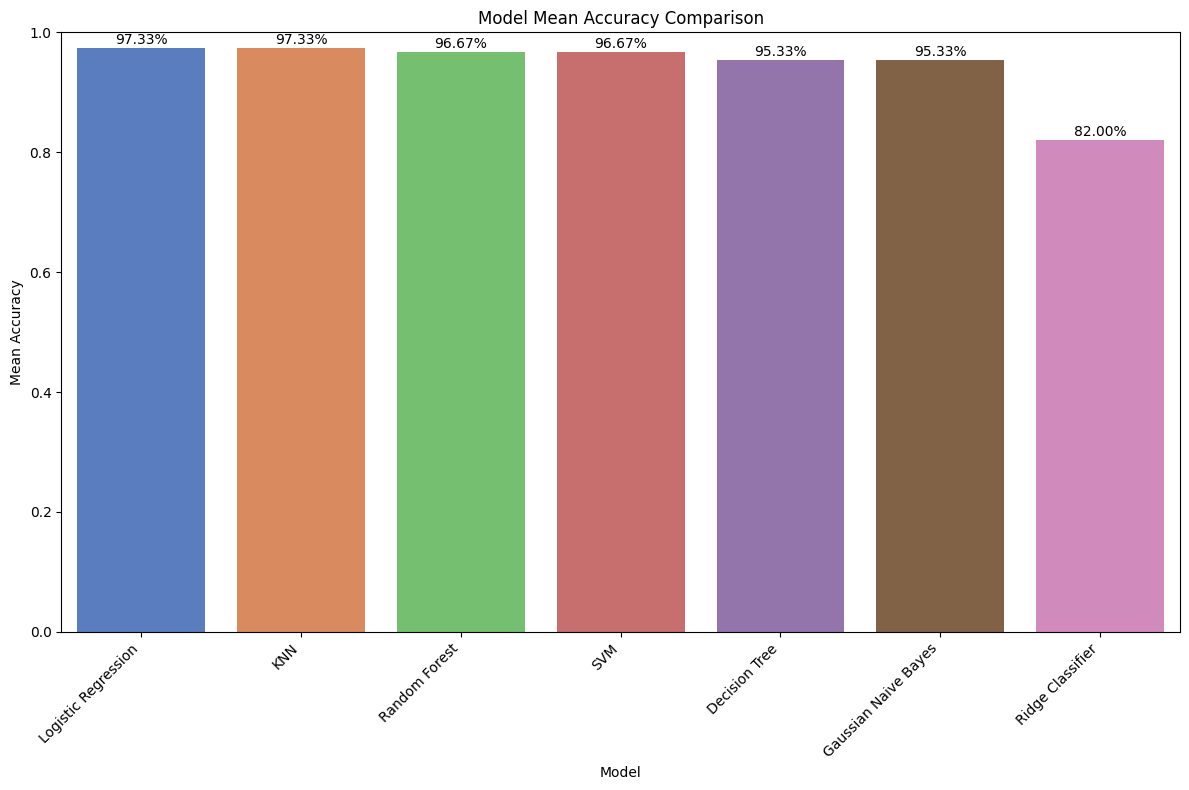

In [109]:
plt.figure(figsize=(12,8))

ax=sns.barplot(
    data=cv_results,
    x="Model",
    y="Mean CV Accuracy",
    palette='muted'
)

plt.xticks(rotation=45, ha='right')
plt.ylim(0,1)
plt.title("Model Mean Accuracy Comparison")
plt.ylabel("Mean Accuracy")
plt.xlabel("Model")
# Add values above bars
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v.get_height()*100:.2f}%" for v in container],
        padding=1
    )
plt.tight_layout()
plt.show()

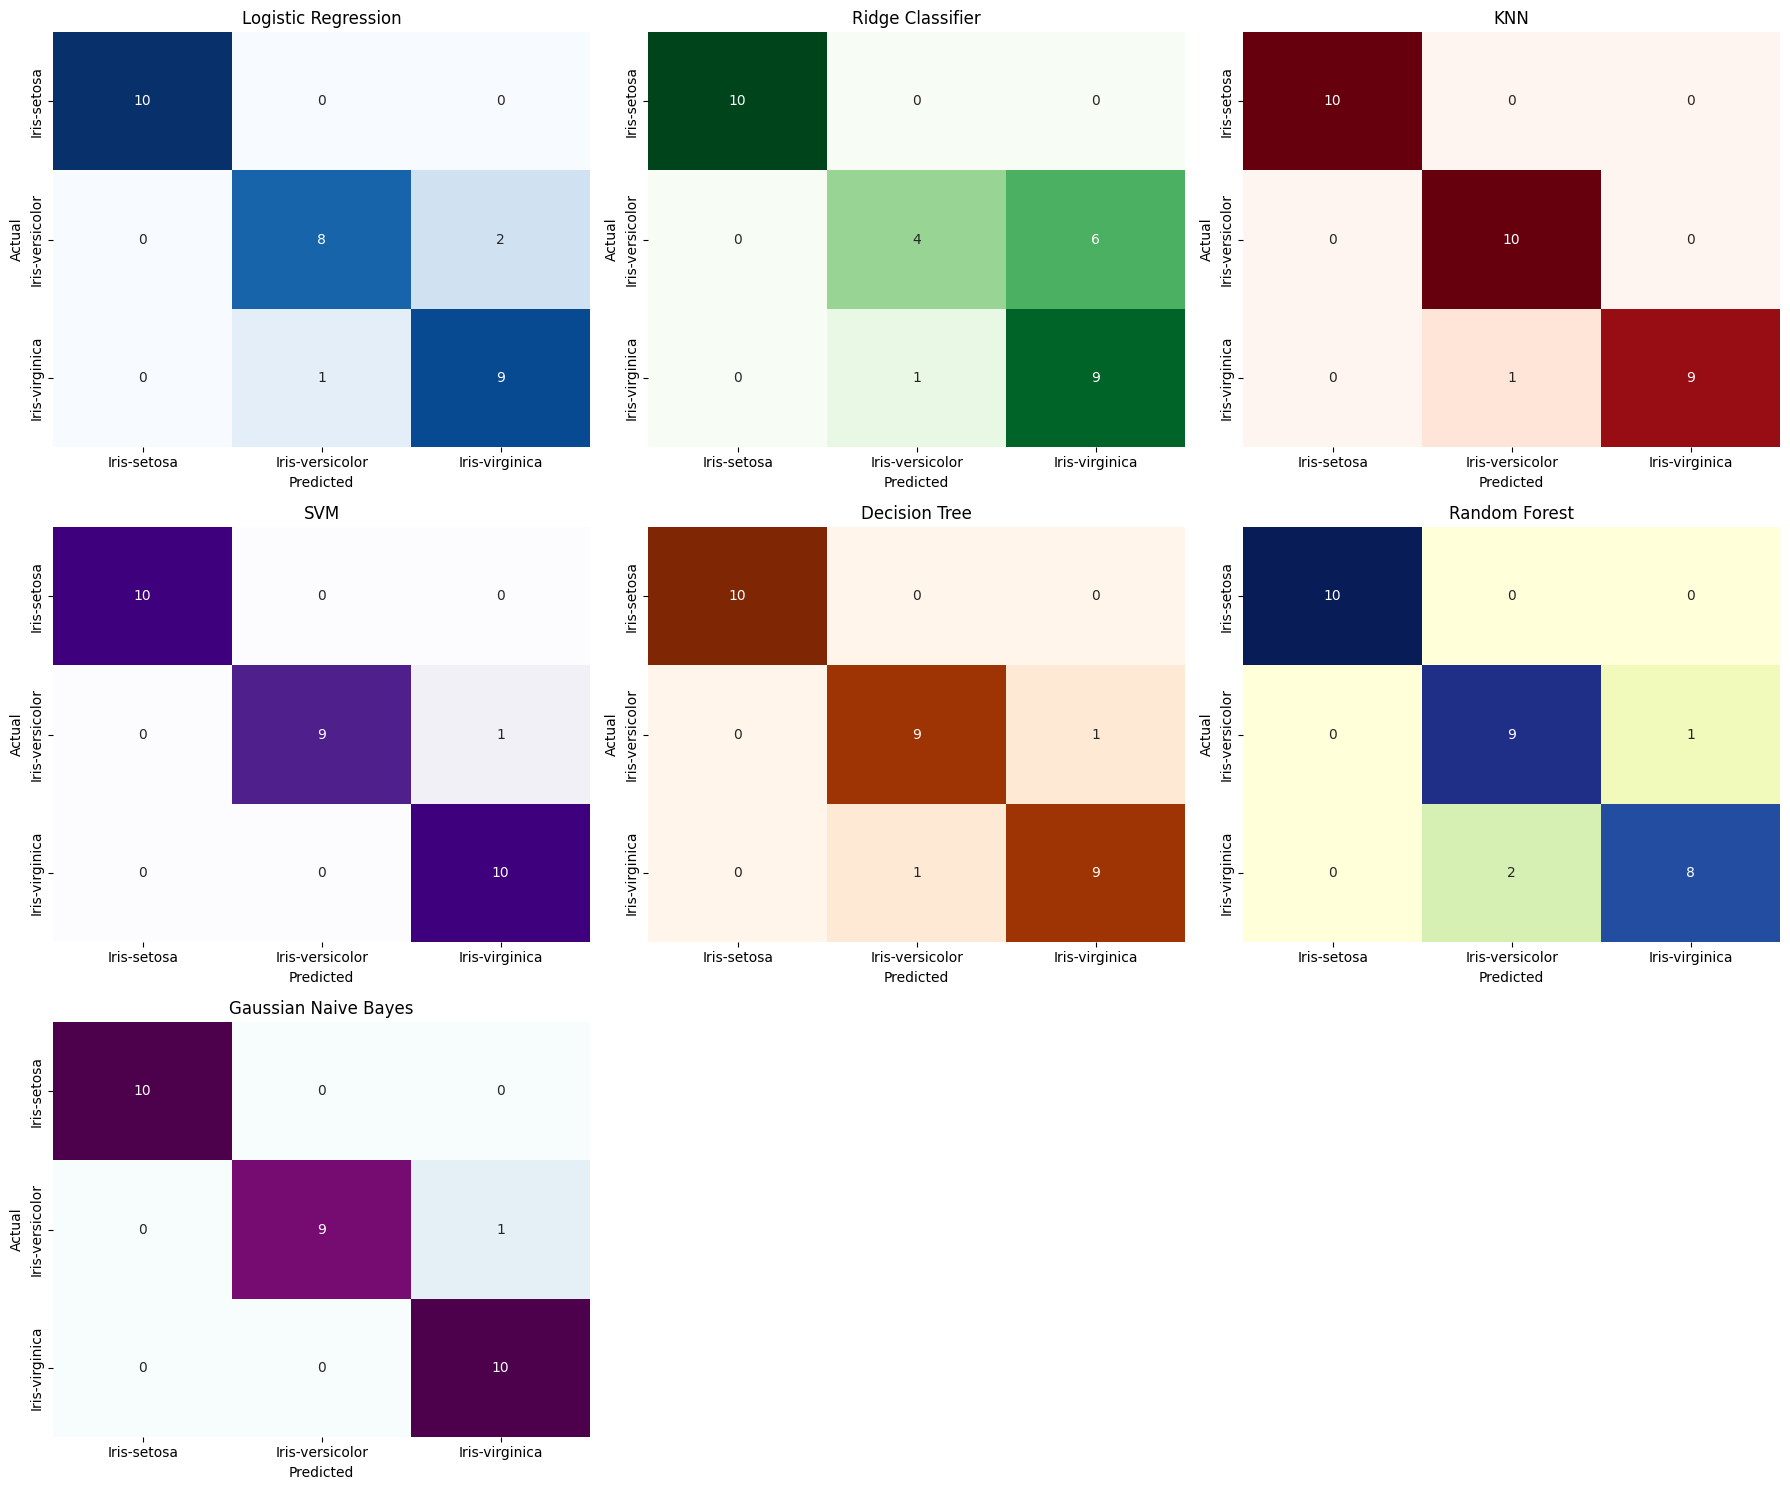

In [110]:
predictions = {
    "Logistic Regression": y_pred_lr,
    "Ridge Classifier": y_pred_ridge,
    "KNN": y_pred_knn,
    "SVM": y_pred_svm,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gaussian Naive Bayes": y_pred_nb
}

cmaps = [
    "Blues",
    "Greens",
    "Reds",
    "Purples",
    "Oranges",
    "YlGnBu",
    "BuPu"
]

plt.figure(figsize=(18, 15))

for i, ((model_name, y_pred), cmap) in enumerate(zip(predictions.items(), cmaps), start=1):

    cm = confusion_matrix(y_test, y_pred)

    plt.subplot(3, 3, i)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        cbar=False,
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )

    plt.title(model_name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [111]:
for model_name, y_pred in predictions.items():

    print("=" * 70)
    print(f"{model_name} - Classification Report")
    print("=" * 70)

    print(classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    ))

Logistic Regression - Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.89      0.80      0.84        10
 Iris-virginica       0.82      0.90      0.86        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30

Ridge Classifier - Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.80      0.40      0.53        10
 Iris-virginica       0.60      0.90      0.72        10

       accuracy                           0.77        30
      macro avg       0.80      0.77      0.75        30
   weighted avg       0.80      0.77      0.75        30

KNN - Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.0

In [112]:
import joblib 
joblib.dump(logistic_regressor,'logistic_regression_model.pkl')
joblib.dump(mm,'scaler.pkl')
joblib.dump(le,'label_encoder.pkl')
joblib.dump(X.columns.tolist(),'features.pkl')

['features.pkl']